In [1]:
import pandas as pd
import csv 
from ast import literal_eval
import os
dfbin = pd.read_csv('Matrix2.csv')
mixnames = dfbin.columns[1:].values
molecules = dfbin['Unnamed: 0'].values
matrix = dfbin.values[0:,1:].astype('float').T
conc_dict = {}
bad_odors = []
with open('concentrations.csv') as conc_f:
    reader = csv.reader(conc_f)
    next(reader, None)
    for row in reader:
        key = row[0]
        inner_dict_keys = literal_eval(row[2])
        inner_dict_values = literal_eval(row[1])
        try:
            conc_dict[key] = dict(zip(inner_dict_keys, inner_dict_values))
        except:
            bad_odors.append(key)
        # if None in inner_dict_keys:
        #     bad_odors.append(key)
        # else:
        #     conc_dict[key] = dict(zip(inner_dict_keys, inner_dict_values))


mix_dict = {}
x = iter(matrix)
for name in mixnames:
    mix_dict[name] = next(x)



# check if the binary matrix and concentration dictionary are consistent
# load a concentration dict
bad_odors = list(pd.read_csv('bad_odors.csv')['Odor Name'])
for mix,bin in mix_dict.items():
    if mix in bad_odors:
        continue
    mix_conc_dict = conc_dict[mix]
    if (sum(bin) != len(mix_conc_dict)):
        print(f"{mix} failed with:  {sum(bin)} BINARY ELTS, {len(mix_conc_dict)} CONCENTRATION ELTS")
        mix_molecules = []
        for i in range(1, len(bin)):
            if bin[i] == 1:
                molecule = molecules[i]
                mix_molecules.append(molecule)
                if molecule not in mix_conc_dict:
                    print(f"MISSING: {molecule}")
        for key in mix_conc_dict.keys():
            if key not in mix_molecules:
                print(f"EXTRA: {key}")

# find amount of missing concentration data, populate concentration matrix
import numpy as np

concentration_matrix = []
total_missing = 0 
total_molecules = 0
for i in range(len(matrix)): # for each mix
    mix = matrix[i] # binary vector for mix
    mixname = mixnames[i]
    if mixname in bad_odors:
        conc_odor = [(np.nan, np.nan, np.nan) for _ in range(mix.size)]
        concentration_matrix.append(conc_odor)
        continue
    mix_conc_dict = conc_dict[mixname] # mixname : concentration for this mix
    conc_odor = [] # [(value, low, high)] for each possible molecule in mix
    for j in range(mix.size): # for each molecule
        if mix[j] == 1: # if the molecule is in the mix
            total_molecules += 1
            molecule = molecules[j] # molecule name
            concentration = mix_conc_dict[molecule]
            if isinstance(concentration, int): # concentration is -1 (missing value)
                conc_odor.append((np.nan, np.nan, np.nan))
                total_missing += 1
            else: # otherwise string with value (xor low/high)
                concentration = concentration.split('-')
                if len(concentration) == 1: # single value
                    if '<' in concentration[0]:
                        conc_odor.append((np.nan, 0., float(concentration[0].split('<')[1]))) # btwn 0 and value after <
                    elif concentration[0] == 'trace': # trace = 0. [can change this]
                        conc_odor.append((0., np.nan, np.nan))
                    elif concentration[0].lower() == 'present': # we already knew this, so missing value
                        conc_odor.append((np.nan, np.nan, np.nan))
                        total_missing += 1
                    else:
                        conc_odor.append((float(concentration[0]), np.nan, np.nan)) # otherwise it's a float value
                elif len(concentration) == 2: # range concentration given
                    start = concentration[0].find('<') + 1 # this < is nonsensical for lower bound (ignore it)
                    low = 0. if concentration[0][start:] == 'trace' else float(concentration[0][start:]) # if "trace" is lower, set to 0.
                    high_start = concentration[1].find('<') + 1 # this < is nonsensical for upper bound (ignore it)
                    conc_odor.append((np.nan, low, float(concentration[1][high_start:])))
                else:
                    conc_odor.append((np.nan, np.nan, np.nan)) # unparseable concentration values
                    total_missing += 1
        else: # molecule not in mix
            conc_odor.append((0., 0., 0.))
    concentration_matrix.append(conc_odor)
concentration_matrix = np.array(concentration_matrix)

print(f"Total missing cells: {total_missing}")
print(f"Total cells: {total_molecules}")
print(f"Mising data percentage: {total_missing / total_molecules * 100}%")

print(concentration_matrix.shape)
print(matrix.shape)

Total missing cells: 51732
Total cells: 90768
Mising data percentage: 56.99365415124274%
(1384, 8729, 3)
(1384, 8729)


In [2]:
# plot molecule distribution
molecule_i = 0
aggregate_col_data = []
max_records, records_i = [], 0
# while (sum(aggregate_col_data) <= 0):
for molecule_i in range(len(molecules)-1): # ignore nan
    mol_col = concentration_matrix[:, molecule_i, :]
    aggregate_col_data = []
    for [val, low, high] in mol_col:
        if val == np.nan and low == np.nan and high == np.nan:
            continue
        if val != -1.:
            aggregate_col_data.append(val)
        else:
            aggregate_col_data.append(low+high/2)
    if molecule_i % 500 == 0: print(molecule_i, sum(aggregate_col_data))
    if len(aggregate_col_data) > len(max_records):
        max_records = aggregate_col_data
        records_i = molecule_i
    # molecule_i += 1
    

0 nan
500 nan
1000 nan
1500 nan
2000 nan
2500 nan
3000 nan
3500 nan
4000 nan
4500 nan
5000 nan
5500 nan
6000 nan
6500 nan
7000 nan
7500 nan
8000 nan
8500 nan


/var/folders/c6/4pyqhs6s5dd_s0wwq651cmmr0000gn/T/ipykernel_30381/4236143075.py:7: RuntimeWarning: invalid value encountered in log10
  logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))


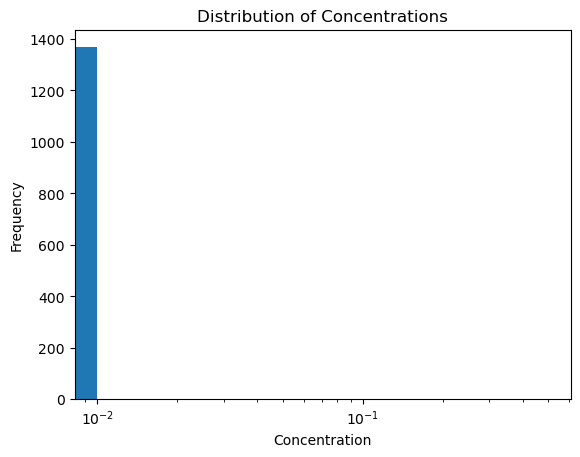

In [3]:
# plot molecule distributions
import matplotlib.pyplot as plt
from seaborn import histplot
# plot a bar plot of aggregate_col_data
plt.figure()
hist, bins, _ = plt.hist(max_records, bins=100)
logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
plt.hist(max_records, bins=logbins)
plt.xlabel('Concentration')
plt.ylabel('Frequency')
# plot on a log scale
plt.xscale('log')
plt.title('Distribution of Concentrations')
plt.show()

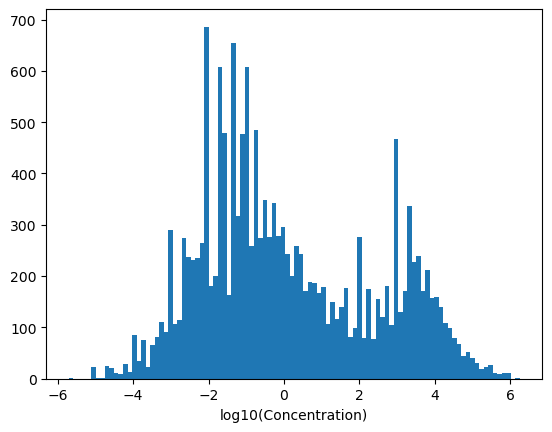

In [4]:
from matplotlib import pyplot as plt
conc = concentration_matrix[:,:,0].flatten()
conc = conc[~np.isnan(conc)]
conc = conc[conc != 0]
plt.hist(np.log10(conc), bins=100)
plt.xlabel('log10(Concentration)')
plt.show()
